Load and explore the dataset

In [1]:
import pandas as pd 
import json 
import re

In [5]:
#### load data
meta_articles = pd.read_parquet("../data/nl/corpus_nl.parquet")
meta_qa_train = pd.read_parquet("../data/nl/train_nl.parquet")
meta_qa_dev = pd.read_parquet("../data/nl/val_nl.parquet")
meta_qa_test = pd.read_parquet("../data/nl/test_nl.parquet")
meta_qa = pd.concat([meta_qa_train, meta_qa_dev, meta_qa_test], ignore_index=True)

In [6]:
### query_id-document_id
qrels = []
for index, row in meta_qa.iterrows():
    for article_id in row.article_ids.split(" "):
        qrels_row = [row.id, article_id, 1]
        qrels.append(qrels_row)
qrels = pd.DataFrame(qrels, columns = ['query_id', 'article_id','score']) 
qrels.to_csv("qrels.csv", index=True)

In [7]:
meta_articles.article[meta_articles.id == 2279].values[0]

'Art. 29. De beslissing om woningen toe te wijzen volgt de chronologische volgorde van de aanvragen in het Register die overeenstemmen met het aantal kamers van de woning die te huur aangeboden wordt, overeenkomstig de reglementering betreffende de in artikel 165 van deze Code bedoelde tegemoetkoming. Toch kunnen andere criteria uit het Toewijzingsreglement in overweging genomen worden om de chronologische volgorde te bepalen, voor zover zij in overeenstemming zijn met de bepalingen van Titel X van deze Code. Die criteria moeten objectief en meetbaar zijn en mogen geen betrekking hebben op de ligging van de verblijfplaats van de kandidaat of het minimumbedrag van zijn inkomen. Hun gewicht voor de toewijzing moet in het Toewijzingsreglement beschreven worden. De chronologische volgorde is bepalend voor de gezinnen wier aanvraag evenveel punten heeft gekregen. Het Reglement dient eveneens te vermelden of men voor de betrokken woning aanspraak kan maken op een huurtoelage. Bij de toewijzi

Explore number of tokens per articles

In [8]:
import pandas as pd
import tiktoken

def describe_token_counts(
    texts: list[str],
    model: str = "text-embedding-3-small"
) -> tuple[list[int], pd.Series]:
    """
    Count tokens for each text and return:
      - list of token counts
      - descriptive statistics (count, mean, std, min, quartiles, max)
    """
    enc = tiktoken.encoding_for_model(model)

    token_counts = [
        len(enc.encode(text))
        for text in texts
    ]

    stats = pd.Series(token_counts).describe()

    return token_counts, stats

art_texts = meta_articles.article.to_list()
num_tokens,  stats = describe_token_counts(art_texts)
stats

count    25982.000000
mean       314.845124
std        536.762264
min          4.000000
25%         93.000000
50%        176.000000
75%        357.000000
max      42285.000000
dtype: float64

In [9]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

def visualize_token_counts(num_tokens, threshold=8191):
    """
    Visualize token counts per document and highlight documents exceeding a threshold.

    Parameters:
    ----------
    num_tokens : list
        List containing token counts for each document.
    threshold : int
        Maximum allowed token count.

    Returns:
    -------
    None
        Displays the scatter plot and prints documents exceeding the threshold.
    """

    over_limit = [
        (i, n) for i, n in enumerate(num_tokens)
        if n > threshold
    ]

    plt.figure(figsize=(10, 5))

    # Plot all documents
    plt.scatter(
        range(len(num_tokens)),
        num_tokens,
        alpha=0.4,
        s=15,
        label=f"≤ {threshold}"
    )

    # Highlight documents over the limit
    if over_limit:
        xs, ys = zip(*over_limit)

        plt.scatter(
            xs,
            ys,
            s=40,
            label=f"> {threshold}",
            zorder=3
        )

        # Label the problematic documents
        for x, y in over_limit:
            plt.annotate(
                str(x),
                (x, y),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8
            )

    # Draw threshold line
    plt.axhline(
        y=threshold,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Article index")
    plt.ylabel("Number of tokens")
    plt.title(
        f"Token count per article "
        f"({len(over_limit)} article(s) over {threshold} tokens)"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print details
    print(f"{len(over_limit)} article(s) exceed {threshold} tokens:")

    for i, n in over_limit:
        print(f"  index {i}: {n} tokens")

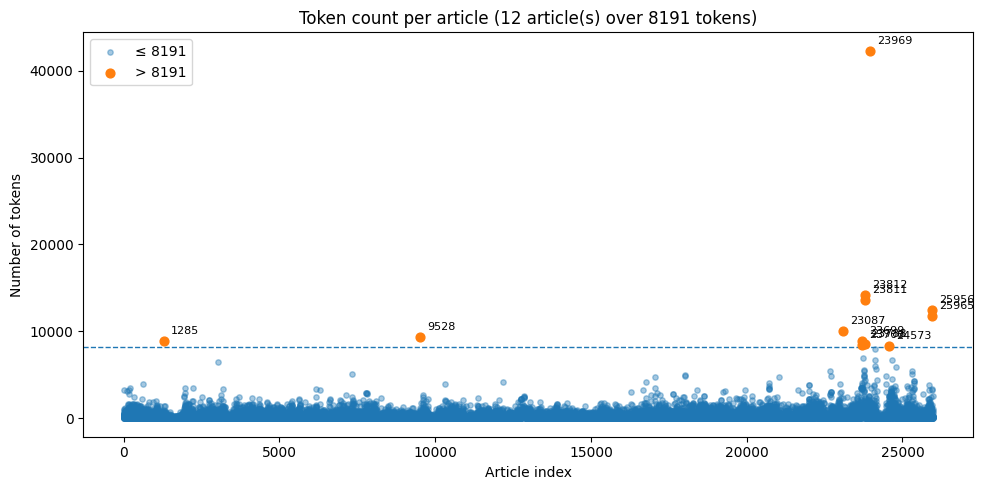

12 article(s) exceed 8191 tokens:
  index 1285: 8941 tokens
  index 9528: 9345 tokens
  index 23087: 10032 tokens
  index 23699: 8936 tokens
  index 23700: 8399 tokens
  index 23788: 8528 tokens
  index 23811: 13657 tokens
  index 23812: 14222 tokens
  index 23969: 42285 tokens
  index 24573: 8297 tokens
  index 25956: 12440 tokens
  index 25965: 11824 tokens


In [10]:
visualize_token_counts(num_tokens)

In [11]:
MAX_TOKENS = 8191

long_docs = [
    {
        "index": i,
        "tokens": n_tokens,
        "text": text,
    }
    for i, (text, n_tokens) in enumerate(zip(art_texts, num_tokens))
    if n_tokens > MAX_TOKENS
]

print(f"Found {len(long_docs)} oversized documents.")

dox_ids = []
for long_doc in long_docs:
    index = long_doc['index']
    ld_id = int(meta_articles.iloc[index, meta_articles.columns.get_loc("id")])
    long_doc['doc_id'] = ld_id
    dox_ids.append(ld_id)

Found 12 oversized documents.


In [15]:
print(dox_ids, long_docs[0]["doc_id"])

[3870, 13153, 26946, 27563, 27564, 27655, 27678, 27679, 27838, 502, 27604, 5435] 3870


In [16]:
### there is no queries related to these long documents
for doc_id in dox_ids:
    print(doc_id)
    print(qrels.loc[qrels["article_id"] == doc_id, "query_id"].values)


3870
[]
13153
[]
26946
[]
27563
[]
27564
[]
27655
[]
27678
[]
27679
[]
27838
[]
502
[]
27604
[]
5435
[]


Chunking based on legal documents' characteristics

In [17]:
import re

def split_by_definitions(text):
    """Split legal text on numbered definitions (1°, 12°, 61/1°, 15°octies etc) 
    or paragraph markers (§ 5., § 7. § 1er.)."""
    pattern = (
    r'(?='
    r'§\s*\d+(?:er)?\.'
    r'|'
    r'\d+(?:/\d+)?°(?:[a-z]+)?\.?\s'
    r')')
    chunks = re.split(pattern, text)
    return [c.strip() for c in chunks if c.strip()]

def split_legal_text(text, max_chunk_size=1500):
    """Split on definition boundaries, then merge into chunks up to max_chunk_size."""
    pieces = split_by_definitions(text)
    chunks, current = [], ""
    for piece in pieces:
        if len(current) + len(piece) > max_chunk_size and current:
            chunks.append(current.strip())
            current = piece
        else:
            current += " " + piece
    if current:
        chunks.append(current.strip())
    return chunks
    

In [18]:
#### see the num of tokens for each chunk
enc = tiktoken.encoding_for_model("text-embedding-3-small")
for long_doc in long_docs:
    doc_chunks = split_legal_text(long_doc['text'], max_chunk_size=15000)
    num_tokens_chunks = [len(enc.encode(chunk)) for chunk in doc_chunks]
    print(num_tokens_chunks)

    #with open(f"{ld_id}.txt", "w", encoding="utf-8") as f:
            #for i, chunk in enumerate(doc_chunks):
                #f.write(f"--- {ld_id}_chunk_{i} ---\n")
                #f.write(chunk)
                #f.write("\n\n")

[4056, 4268, 617]
[4691, 4823, 100]
[4670, 4821, 685]
[4083, 4076, 776]
[4536, 3863]
[3147, 4727, 654]
[4474, 4313, 3847, 1021]
[4460, 4228, 4445, 1087]
[4780, 3405, 3801, 3750, 4434, 2191, 6551, 3405, 3648, 3365, 3082]
[4396, 3911]
[4361, 4370, 3739]
[4612, 4689, 2814]


In [33]:
chunks = {}
for long_doc in long_docs:
    ld_id = long_doc['doc_id']
    chunks[ld_id] = split_legal_text(long_doc['text'], max_chunk_size=15000)
long_dox = [long_doc['doc_id'] for long_doc in long_docs ]

new_rows = []

for doc_id in long_dox:
    # Get the original row
    original = meta_articles.loc[meta_articles["id"] == doc_id]
    original = original.iloc[0]

    # Create one row per chunk
    for i, chunk in enumerate(chunks[doc_id]):
        row = original.copy()
        row["article"] = chunk
        row["reference"] =  row["reference"]+ f" chunk {str(i)}"
        if len(str(doc_id))>3:
            row["id"] = int(f"{doc_id}{i}")
        else:
            row["id"] = int(f"{doc_id}{i}{i}")
        new_rows.append(row)

# Create dataframe of new rows
new_rows_df = pd.DataFrame(new_rows)

new_rows_df.head()


,id,article,reference
1285,38700,"Art. 488bis.<Ingevoegd bij W 18-07-1991, art. ...","Art. 488bis Burgerlijk wetboek (boek I, titel ..."
1285,38701,§ 2. In dit schriftelijk verslag worden minste...,"Art. 488bis Burgerlijk wetboek (boek I, titel ..."
1285,38702,§ 3. Onverminderd § 2 is de beschermde persoon...,"Art. 488bis Burgerlijk wetboek (boek I, titel ..."
9528,131530,Art. 3.Voor de toepassing van deze Codex wordt...,"Art. 3 Wet houdende de Spoorcodex (titel 1, ho..."
9528,131531,"9° ""Net""; ""Netwerk"": a) inzake interoperabilit...","Art. 3 Wet houdende de Spoorcodex (titel 1, ho..."


In [34]:
new_rows_df

,id,article,reference
1285,38700,"Art. 488bis.<Ingevoegd bij W 18-07-1991, art. ...","Art. 488bis Burgerlijk wetboek (boek I, titel ..."
1285,38701,§ 2. In dit schriftelijk verslag worden minste...,"Art. 488bis Burgerlijk wetboek (boek I, titel ..."
1285,38702,§ 3. Onverminderd § 2 is de beschermde persoon...,"Art. 488bis Burgerlijk wetboek (boek I, titel ..."
9528,131530,Art. 3.Voor de toepassing van deze Codex wordt...,"Art. 3 Wet houdende de Spoorcodex (titel 1, ho..."
9528,131531,"9° ""Net""; ""Netwerk"": a) inzake interoperabilit...","Art. 3 Wet houdende de Spoorcodex (titel 1, ho..."
9528,131532,"5° ""Verordening (EU) 2016/679"": Verordening (E...","Art. 3 Wet houdende de Spoorcodex (titel 1, ho..."
23087,269460,Art. 5.Tenzij hiervan uitdrukkelijk wordt afge...,Art. 5 Wet betreffende de verzekeringen chunk 0
23087,269461,"4° ""Bijkantoor"" : ieder agentschap of bijkanto...",Art. 5 Wet betreffende de verzekeringen chunk 1
23087,269462,"5° ""verzekeringsdistributeur"": een verzekering...",Art. 5 Wet betreffende de verzekeringen chunk 2
23699,275630,Art. 35bis. § 1. De Koning bevestigt de lijst ...,Art. 35bis Wet betreffende de verplichte verze...


In [35]:
import tiktoken

enc = tiktoken.encoding_for_model("text-embedding-3-small")
texts = new_rows_df.article.to_list()
num_tokens_ = []
for tex in texts:
    num_tokens = len(enc.encode(tex))
    num_tokens_.append(num_tokens)
pd.Series(num_tokens_).describe()

count      44.000000
mean     3585.727273
std      1441.014474
min       100.000000
25%      3310.500000
50%      4066.000000
75%      4463.500000
max      6551.000000
dtype: float64

In [36]:
new_ids = new_rows_df["id"].tolist()

existing_ids = meta_articles.loc[
    meta_articles["id"].isin(new_ids), "id"
].tolist()

if existing_ids:
    print(f"{len(existing_ids)} IDs already exist:")
    print(existing_ids)
else:
    print("No new IDs already exist in meta_articles.id.")


No new IDs already exist in meta_articles.id.


In [37]:
# Remove the original long documents and append the chunked versions
articles = pd.concat(
    [
        meta_articles.loc[~meta_articles["id"].isin(long_dox)],
        new_rows_df,
    ],
    ignore_index=True,
)

In [38]:
art_texts = articles.article.to_list()
num_tokens,  stats = describe_token_counts(art_texts)
stats

count    26014.000000
mean       314.491120
std        443.297734
min          4.000000
25%         93.000000
50%        176.000000
75%        358.000000
max       7957.000000
dtype: float64

In [39]:
##make parquet files
articles.to_parquet("parquet_data/corpus_nl.parquet", index=False)
meta_qa.to_parquet("parquet_data/qa_nl.parquet", index=False)
qrels.to_parquet("parquet_data/qrels_nl.parquet", index=False)